# SSDU 데모 — 단일 스캔(zero-shot) 자기지도 복원

SSDU의 자기지도(획득 마스크 Ω를 **Θ(DC)/Λ(loss)** 로 나눠 Λ k-space를 맞히는 학습)는
**단일 스캔에도 그대로 적용** 가능하다 (zero-shot). 한 스캔만으로 학습한다.
- **ZS-SSL과 차이**: ZS-SSL은 Ω에서 검증셋 Γ를 떼어 early stopping. 이 SSDU 데모는 Γ 없이 고정 epoch (핵심 Θ/Λ 자기지도만).
- **비교 기준(GT) = 우리 SENSE combination** (recon이 SENSE 도메인 출력).

In [1]:
import os, sys, time, glob
sys.path.insert(0, '/home/sonwonjun/research/MRRecon/code')
import numpy as np, torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from mrrecon.config import Config
from mrrecon.data.loaders import read_slice
from mrrecon.data.masks import undersampling_mask
from mrrecon.data.datasets import ZeroShotDataset
from mrrecon.models import build_unrolled
from mrrecon.losses import MixL1L2Loss
from mrrecon.metrics import all_metrics, match_scale
from mrrecon.data.transforms import sense_combine_np
from mrrecon.core.common import center_crop
from mrrecon.core.inference import recon_unrolled

cfg=Config(); cfg.tissue='knee'; cfg.device='cuda' if torch.cuda.is_available() else 'cpu'
cfg.model='ssdu'; cfg.nb_unroll_blocks=5; cfg.res_blocks=4; cfg.cg_iter=5; cfg.mu=0.05
cfg.acc_rate=4; cfg.acs_lines=24; cfg.mask_type='vds_lustig'; cfg.rho=0.4
cfg.zs_val_rho=0.0; cfg.zs_num_splits=8; cfg.lr=5e-4; cfg.epochs=40; cfg.crop_size=320; cfg.seed=1234
dev=torch.device(cfg.device); print('device',dev)

device cuda


## 0. 데이터 먼저 보기 — k-space / mask / undersampled (+ zero-filled SSIM·PSNR)

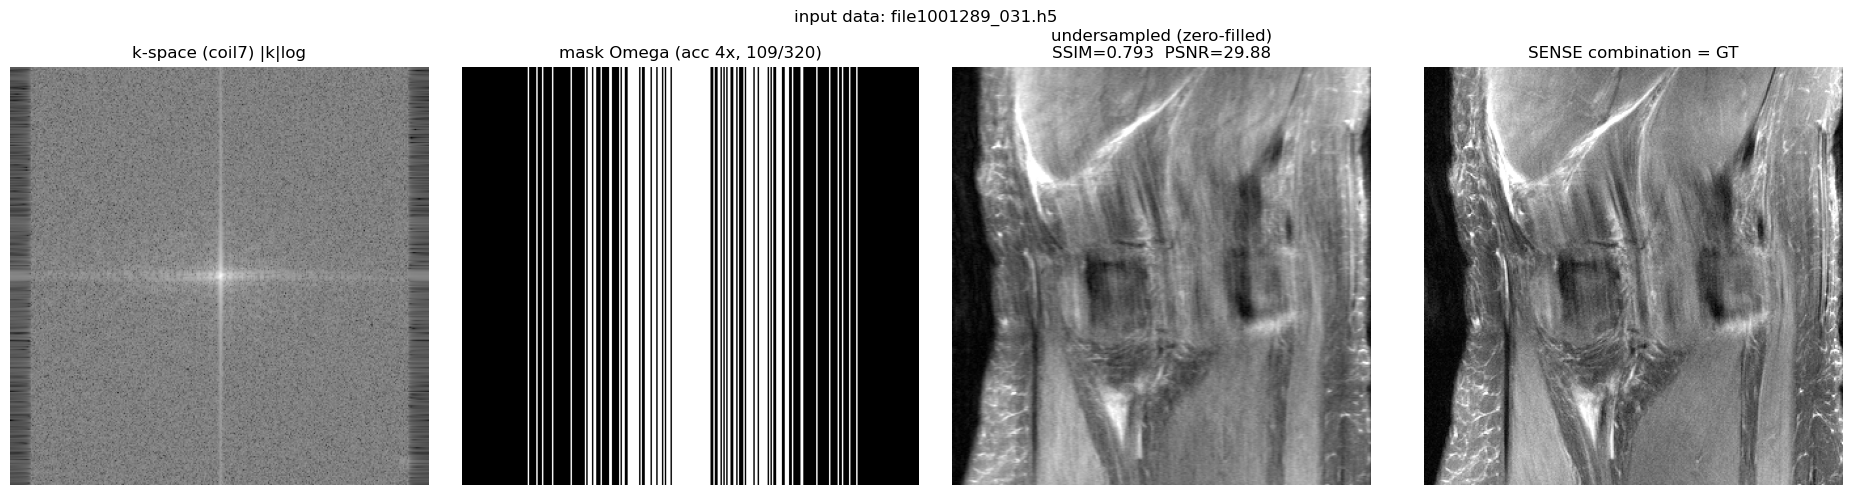

zero-filled vs SENSE-GT : SSIM=0.7932  PSNR=29.878  NMSE=0.01087


In [2]:
# 한 test 스캔 + 언더샘플 마스크 Omega
files=sorted(glob.glob('/mnt/d/research/MRRecon/knee/test/*.h5'))
sf=files[len(files)//2]
kspace,sens,rss=read_slice(sf,crop_size=cfg.crop_size)
H,W=kspace.shape[1:]
omega=undersampling_mask((H,W),cfg.acc_rate,cfg.acs_lines,cfg.mask_type,rng=np.random.default_rng(cfg.seed),vds_power=cfg.vds_power)

sense_gt=np.abs(sense_combine_np(kspace,sens))             # GT = SENSE combination (fully-sampled)
zf=np.abs(sense_combine_np(kspace*omega[None],sens))       # zero-filled (undersampled) SENSE
gtc,zfc=center_crop(sense_gt),center_crop(zf)
mzf=all_metrics(gtc,match_scale(gtc,zfc))                  # zero-filled vs SENSE GT
line=lambda m:m[m.shape[0]//2]

fig,ax=plt.subplots(1,4,figsize=(19,5))
ax[0].imshow(np.log(np.abs(kspace[7])+1e-9),cmap='gray'); ax[0].set_title('k-space (coil7) |k|log'); ax[0].axis('off')
ax[1].imshow(omega,cmap='gray',aspect='auto'); ax[1].set_title(f'mask Omega (acc {cfg.acc_rate}x, {int(line(omega).sum())}/{W})'); ax[1].axis('off')
ax[2].imshow(zfc,cmap='gray',vmax=0.6*gtc.max()); ax[2].set_title(f'undersampled (zero-filled)\nSSIM={mzf["ssim"]:.3f}  PSNR={mzf["psnr"]:.2f}'); ax[2].axis('off')
ax[3].imshow(gtc,cmap='gray',vmax=0.6*gtc.max()); ax[3].set_title('SENSE combination = GT'); ax[3].axis('off')
plt.suptitle(f'input data: {sf.split(chr(47))[-1]}'); plt.tight_layout(); plt.show()
print(f'zero-filled vs SENSE-GT : SSIM={mzf["ssim"]:.4f}  PSNR={mzf["psnr"]:.3f}  NMSE={mzf["nmse"]:.5f}')


## 1. Θ/Λ 분할 (단일 스캔, 매 step 재분할)
Γ 없이(`zs_val_rho=0`) Ω 전체를 매 step Θ/Λ로 재분할한다.

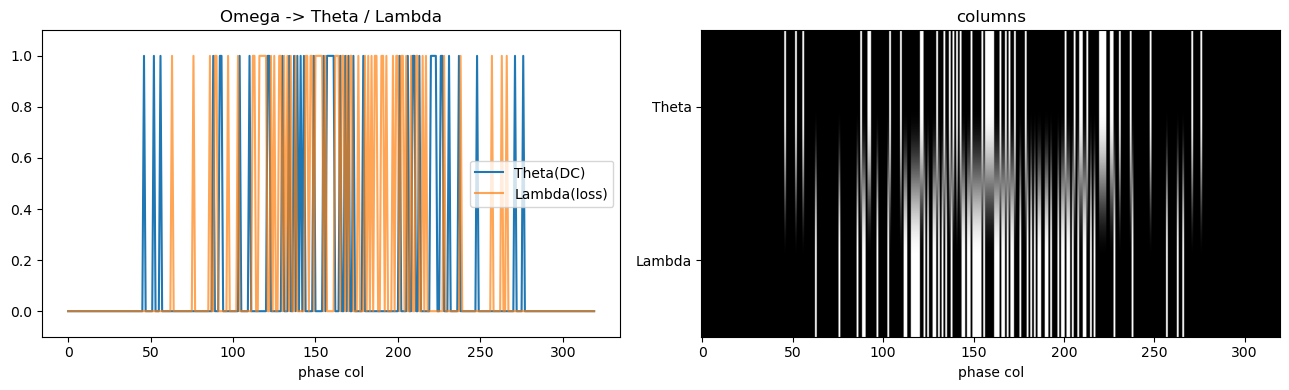

Theta=44  Lambda=65


In [3]:
ds=ZeroShotDataset(cfg,kspace,sens,omega)
b=ds[0]; theta=b['trn_mask'][0].numpy(); lam=b['loss_mask'][0].numpy()
fig,ax=plt.subplots(1,2,figsize=(13,4))
ax[0].plot(line(theta),label='Theta(DC)'); ax[0].plot(line(lam),label='Lambda(loss)',alpha=0.7)
ax[0].set_title('Omega -> Theta / Lambda'); ax[0].legend(); ax[0].set_ylim(-0.1,1.1); ax[0].set_xlabel('phase col')
ax[1].imshow(np.stack([line(theta),line(lam)]),aspect='auto',cmap='gray'); ax[1].set_yticks([0,1]); ax[1].set_yticklabels(['Theta','Lambda']); ax[1].set_title('columns'); ax[1].set_xlabel('phase col')
plt.tight_layout(); plt.show()
print(f'Theta={int(line(theta).sum())}  Lambda={int(line(lam).sum())}')

## 2. 모델 + 학습 (단일 스캔, 고정 epoch)

ep  1 train=0.5535  recon vs SENSE-GT: SSIM=0.8261 PSNR=31.93


ep  5 train=0.5392  recon vs SENSE-GT: SSIM=0.8343 PSNR=32.10


ep 10 train=0.5365  recon vs SENSE-GT: SSIM=0.8375 PSNR=32.18


ep 15 train=0.5344  recon vs SENSE-GT: SSIM=0.8367 PSNR=32.15


ep 20 train=0.5262  recon vs SENSE-GT: SSIM=0.8348 PSNR=32.10


ep 25 train=0.5255  recon vs SENSE-GT: SSIM=0.8339 PSNR=32.04


ep 30 train=0.5228  recon vs SENSE-GT: SSIM=0.8342 PSNR=32.12


ep 35 train=0.5157  recon vs SENSE-GT: SSIM=0.8353 PSNR=32.23


ep 40 train=0.5236  recon vs SENSE-GT: SSIM=0.8339 PSNR=32.16
done 90s


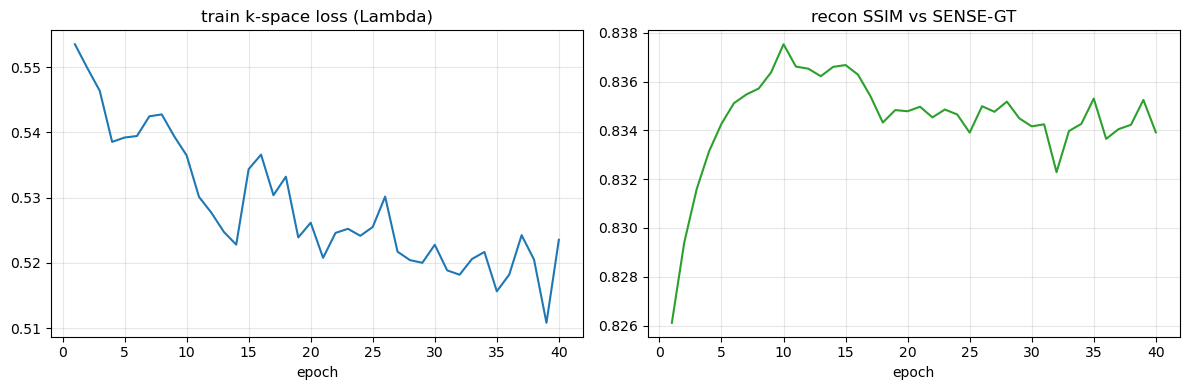

In [4]:
torch.manual_seed(cfg.seed); np.random.seed(cfg.seed)
model=build_unrolled(cfg).to(dev); opt=torch.optim.Adam(model.parameters(),lr=cfg.lr); loss_fn=MixL1L2Loss().to(dev)
dl=DataLoader(ds,batch_size=1,shuffle=False,num_workers=0)
def eval_sense(model):
    ref,zfb,rec=recon_unrolled(model,kspace,sens,omega,dev)   # ref=SENSE GT, zfb=zero-filled
    rc,rf,zc=center_crop(np.abs(rec)),center_crop(ref),center_crop(zfb)
    return (all_metrics(rf,match_scale(rf,rc)), all_metrics(rf,match_scale(rf,zc)), np.abs(rec), ref, zfb)

def to_dev(b): return (b['x_in'].to(dev),b['sens_maps'].to(dev),b['ref_kspace'].to(dev),b['trn_mask'].to(dev),b['loss_mask'].to(dev))
hist=[]; t0=time.time()
for ep in range(cfg.epochs):
    model.train(); el=0;n=0
    for bb in dl:
        x,s,rk,tr,lm=to_dev(bb); _,_,nw=model(x,s,tr,lm); loss=loss_fn(nw,rk)
        opt.zero_grad(); loss.backward(); opt.step(); el+=loss.item(); n+=1
    el/=n; mr,_,_,_,_=eval_sense(model); hist.append({'ep':ep+1,'train':el,'ssim':mr['ssim'],'psnr':mr['psnr']})
    if (ep+1)%5==0 or ep==0: print(f'ep{ep+1:3d} train={el:.4f}  recon vs SENSE-GT: SSIM={mr["ssim"]:.4f} PSNR={mr["psnr"]:.2f}')
print(f'done {time.time()-t0:.0f}s')
ep=[h['ep'] for h in hist]
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].plot(ep,[h['train'] for h in hist]); ax[0].set_title('train k-space loss (Lambda)'); ax[0].set_xlabel('epoch'); ax[0].grid(alpha=0.3)
ax[1].plot(ep,[h['ssim'] for h in hist],'C2'); ax[1].set_title('recon SSIM vs SENSE-GT'); ax[1].set_xlabel('epoch'); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. 최종 복원 vs SENSE-GT (zero-filled / recon 의 SSIM·PSNR)

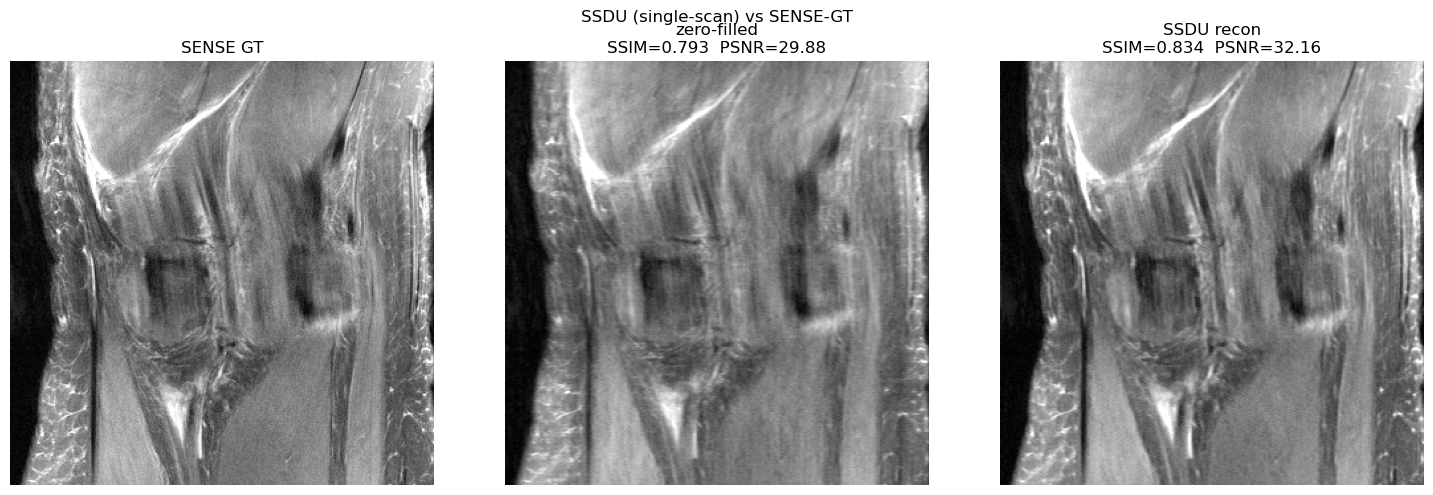

zero-filled : SSIM=0.7932  PSNR=29.878
SSDU recon  : SSIM=0.8339  PSNR=32.160  NMSE=0.00643


In [5]:
mr,mz,rec,ref,zfb=eval_sense(model)
gtc=center_crop(ref); zc=center_crop(np.abs(zfb)); rc=center_crop(np.abs(rec))
fig,ax=plt.subplots(1,3,figsize=(15,5))
ax[0].imshow(gtc,cmap='gray',vmax=0.6*gtc.max()); ax[0].set_title('SENSE GT'); ax[0].axis('off')
ax[1].imshow(match_scale(gtc,zc),cmap='gray',vmax=0.6*gtc.max()); ax[1].set_title(f'zero-filled\nSSIM={mz["ssim"]:.3f}  PSNR={mz["psnr"]:.2f}'); ax[1].axis('off')
ax[2].imshow(match_scale(gtc,rc),cmap='gray',vmax=0.6*gtc.max()); ax[2].set_title(f'SSDU recon\nSSIM={mr["ssim"]:.3f}  PSNR={mr["psnr"]:.2f}'); ax[2].axis('off')
plt.suptitle('SSDU (single-scan) vs SENSE-GT'); plt.tight_layout(); plt.show()
print(f'zero-filled : SSIM={mz["ssim"]:.4f}  PSNR={mz["psnr"]:.3f}')
print(f'SSDU recon  : SSIM={mr["ssim"]:.4f}  PSNR={mr["psnr"]:.3f}  NMSE={mr["nmse"]:.5f}')

**요약**: SSDU 자기지도(Θ/Λ k-space loss)를 단일 스캔에 적용. GT는 SENSE combination, zero-filled/recon 모두 SENSE-GT 기준 SSIM·PSNR로 비교.